### import the packages

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import scipy.stats as stats

In [94]:
from sklearn.model_selection import train_test_split
# import sklearn.model_selection.train_test_split as train_test_split

import statsmodels.formula.api as smf
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

from sklearn.linear_model import LinearRegression
# sklearn - scikit learn

### UDFs

In [95]:
def continuous_var_summary( x ):
    
    # freq and missings
    n_total = x.shape[0]
    n_miss = x.isna().sum()
    perc_miss = n_miss * 100 / n_total
    
    # outliers - iqr
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    lc_iqr = q1 - 1.5 * iqr
    uc_iqr = q3 + 1.5 * iqr
    
    return pd.Series( [ x.dtype, x.nunique(), n_total, x.count(), n_miss, perc_miss,
                       x.sum(), x.mean(), x.std(), x.var(), 
                       lc_iqr, uc_iqr, 
                       x.min(), x.quantile(0.01), x.quantile(0.05), x.quantile(0.10), 
                       x.quantile(0.25), x.quantile(0.5), x.quantile(0.75), 
                       x.quantile(0.90), x.quantile(0.95), x.quantile(0.99), x.max() ], 
                     
                    index = ['dtype', 'cardinality', 'n_tot', 'n', 'nmiss', 'perc_miss',
                             'sum', 'mean', 'std', 'var',
                        'lc_iqr', 'uc_iqr',
                        'min', 'p1', 'p5', 'p10', 'p25', 'p50', 'p75', 'p90', 'p95', 'p99', 'max']) 

### data import

In [96]:
cars = pd.read_csv('D:/sampledata/car_sales.csv')

In [97]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Manufacturer            157 non-null    object 
 1   Model                   157 non-null    object 
 2   Sales_in_thousands      157 non-null    float64
 3   four_year_resale_value  121 non-null    float64
 4   Vehicle_type            157 non-null    object 
 5   Price_in_thousands      155 non-null    float64
 6   Engine_size             156 non-null    float64
 7   Horsepower              156 non-null    float64
 8   Wheelbase               156 non-null    float64
 9   Width                   156 non-null    float64
 10  Length                  156 non-null    float64
 11  Curb_weight             155 non-null    float64
 12  Fuel_capacity           156 non-null    float64
 13  Fuel_efficiency         154 non-null    float64
 14  Latest_Launch           157 non-null    ob

In [98]:
cars.head()

,Manufacturer,Model,Sales_in_thousands,four_year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639


In [99]:
cars.nunique()

Manufacturer               30
Model                     156
Sales_in_thousands        157
four_year_resale_value    117
Vehicle_type                2
Price_in_thousands        152
Engine_size                31
Horsepower                 66
Wheelbase                  88
Width                      78
Length                    127
Curb_weight               147
Fuel_capacity              55
Fuel_efficiency            20
Latest_Launch             130
Power_perf_factor         154
dtype: int64

#### separate the categorical vs continuous variables

In [100]:
# creating a copy of the data
cars_continuous = cars.select_dtypes('float64')
cars_categorical = cars.select_dtypes('object')

# creating the variables with column names
cars_cat_variables = cars.select_dtypes('object').columns
cars_conti_variables = cars.select_dtypes('float64').columns

### data summary

In [101]:
cars_continuous.apply(continuous_var_summary)
# cars.loc[:, cars_conti_variables ].apply(continuous_var_summary)

,Sales_in_thousands,four_year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Power_perf_factor
dtype,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
cardinality,157,117,152,31,66,88,78,127,147,55,20,154
n_tot,157,157,157,157,157,157,157,157,157,157,157,157
n,157,121,155,156,156,156,156,156,155,156,154,155
nmiss,0,36,2,1,1,1,1,1,2,1,3,2
perc_miss,0.0,22.929936,1.273885,0.636943,0.636943,0.636943,0.636943,0.636943,1.273885,0.636943,1.910828,1.273885
sum,8320.698,2186.83,4245.567,477.5,29008.0,16768.0,11099.4,29225.6,523.594,2800.5,3672.0,11941.756636
mean,52.998076,18.072975,27.390755,3.060897,185.948718,107.487179,71.15,187.34359,3.378026,17.951923,23.844156,77.043591
std,68.029422,11.453384,14.351653,1.044653,56.700321,7.641303,3.451872,13.431754,0.630502,3.887921,4.282706,25.142664
var,4628.002257,131.180007,205.969949,1.0913,3214.926385,58.389512,11.915419,180.412023,0.397532,15.115932,18.341567,632.153558


#### outlier treatment

In [102]:
cars_continuous = cars_continuous.apply( lambda x: x.clip( lower = x.quantile(0.01), upper = x.quantile(0.99) ) )

#### missing value treatment

In [103]:
cars_continuous = cars_continuous.apply( lambda x: x.fillna( x.mean() ) )

#### summary

In [104]:
cars_continuous.apply(continuous_var_summary)

,Sales_in_thousands,four_year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Power_perf_factor
dtype,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
cardinality,155,116,151,30,65,88,77,126,146,55,20,153
n_tot,157,157,157,157,157,157,157,157,157,157,157,157
n,157,157,157,157,157,157,157,157,157,157,157,157
nmiss,0,0,0,0,0,0,0,0,0,0,0,0
perc_miss,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sum,8025.5292,2829.141298,4290.61297,478.860064,29095.622436,16867.536538,11173.619551,29411.272949,530.528485,2817.848077,3731.298701,12065.384534
mean,51.11802,18.020008,27.328745,3.050064,185.322436,107.436538,71.169551,187.332949,3.379162,17.948077,23.766234,76.849583
std,57.722699,9.80668,13.973525,0.979125,52.646914,7.400461,3.379455,13.07823,0.617766,3.807591,3.956157,23.691622
var,3331.909938,96.170969,195.259402,0.958686,2771.697606,54.766822,11.420718,171.04011,0.381634,14.497753,15.651182,561.292961


#### summary of categorical variables

In [105]:
cars_categorical.describe().T

,count,unique,top,freq
Manufacturer,157,30,Ford,11
Model,157,156,Neon,2
Vehicle_type,157,2,Passenger,116
Latest_Launch,157,130,10/20/2009,2


In [106]:
cars_categorical = pd.get_dummies( cars_categorical.loc[:, ['Manufacturer', 'Vehicle_type']], drop_first = True )

### combine the cat and conti variables

In [107]:
cars_new = pd.concat([cars_categorical, cars_continuous], axis = 1 )

In [108]:
cars_new.shape

(157, 42)

#### check assumptions

C:\Users\DELL\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


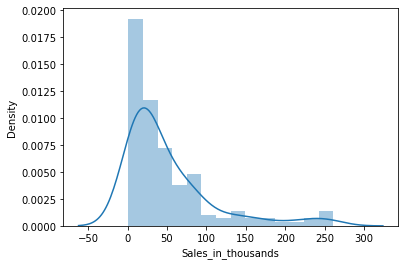

In [109]:
# Very first assumtion is that all the variables should be normally distributed, however that can't be possible
# However we have to be atleast strict about the dependant Y variable

# Distribution of variables
sns.distplot(cars_new.Sales_in_thousands)
plt.show()
# this distribution is highly skewed

# Notes:
#-----------------------------------------------------
# 1. if we get skewed data, then we have to transform the data and there are multiple methods to go about it
# 2. most commonly used and which works on most of the data is log transformation
# 3. Ideally we can do this for each of the dependant variable as well, 
#    however it will depend on amount of data and the amount of analytical rigour
# 4. In no case we can proceed if dependant variable is not normal/near to normal distributed

In [110]:
cars_new.Sales_in_thousands.skew()

1.9924932920508793

C:\Users\DELL\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


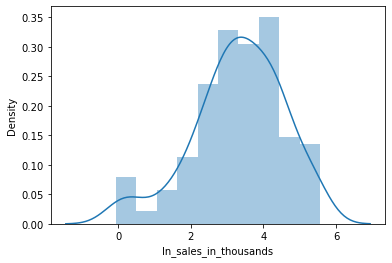

In [111]:
# Note: good practice is to take the log of the data plus 1, bcoz we don't have log of zero defined
# In thios data its not required as sales are always greater than zero

# apply log transformation: log is rescalling the data and making the distribution normal
cars_new.loc[:, 'ln_sales_in_thousands'] = np.log( cars_new.Sales_in_thousands )

# Distribution of variables
sns.distplot(cars_new.ln_sales_in_thousands)
plt.show()

In [112]:
cars_new.ln_sales_in_thousands.skew()

-0.5925861100519006

In [123]:
# rename the variable to follow INC rules
cars_new.rename( columns = {'Manufacturer_Mercedes-B': 'Manufacturer_Mercedes_B'}, inplace = True )

### Variable selection

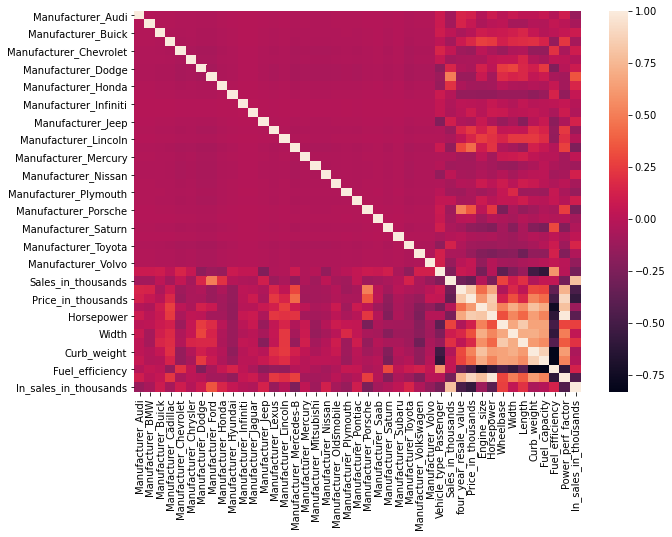

In [116]:
plt.figure( figsize=(10, 7) )
sns.heatmap( cars_new.corr() )
plt.show()

In [119]:
cars_new.corr().to_excel('D:/corr.xlsx')

#### significance

In [120]:
# Feature Selection based on importance
from sklearn.feature_selection import f_regression

In [125]:
X_vars = cars_new.columns.difference(['Sales_in_thousands', 'ln_sales_in_thousands'])

In [128]:
f_values, p_val = f_regression( cars_new.loc[:, X_vars], cars_new.ln_sales_in_thousands )

In [132]:
f_reg = pd.DataFrame([X_vars, f_values, p_val]).T

In [134]:
f_reg.columns = ['Featrues', 'F_Value', 'P_Value']

In [140]:
features = list( f_reg.loc[ f_reg.P_Value <= 0.1, 'Featrues' ] )

In [142]:
len(features)

16

#### multicolinearity

In [153]:
# import the packages for vif
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices

In [167]:
model_param = 'ln_sales_in_thousands ~ ' + ' + '.join(features)

In [189]:
model_param = '''ln_sales_in_thousands ~ Fuel_efficiency + 
        Manufacturer_Audi + Manufacturer_Ford + Manufacturer_Honda + Manufacturer_Mercedes_B + 
        Manufacturer_Plymouth + Manufacturer_Porsche + Manufacturer_Toyota + Manufacturer_Volvo + 
        Price_in_thousands + Vehicle_type_Passenger + Wheelbase '''

In [190]:
# separate the Y and X variables
y, X = dmatrices( model_param, cars_new, return_type = 'dataframe' )

# For each X, calculate VIF and save in dataframe
vif = pd.DataFrame()

vif['Features'] = X.columns
vif['VIF Factor'] = [ variance_inflation_factor(X.values, i) for i in range(X.shape[1]) ]

In [191]:
# display the output
vif.round(1).sort_values(by = 'VIF Factor', ascending = False)

,Features,VIF Factor
0,Intercept,618.2
1,Fuel_efficiency,3.9
10,Price_in_thousands,3.2
11,Vehicle_type_Passenger,2.5
12,Wheelbase,1.6
5,Manufacturer_Mercedes_B,1.5
7,Manufacturer_Porsche,1.4
8,Manufacturer_Toyota,1.2
2,Manufacturer_Audi,1.1
3,Manufacturer_Ford,1.1


In [195]:
features = list( vif.loc[1:, 'Features'] )

### train test split

In [143]:
# from sklearn.model_selection import train_test_split
# import statsmodels.formula.api as smf

# this is the method1, which will be used for the input to smf
train, test = train_test_split( cars_new, test_size = 0.3, random_state = 1 )

In [144]:
X_vars = cars_new.columns.difference(['ln_sales_in_thousands', 'Sales_in_thousands'])
y_var = 'ln_sales_in_thousands'

In [145]:
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LinearRegression

# this is the method2, which will be used for the input to sklearn based methods
X_train, X_test, y_train, y_test = train_test_split( cars_new[X_vars], cars_new[y_var], 
                                                        test_size = 0.3, random_state = 1 )

### Define and fit the model

In [88]:
' + '.join( ['a', 'b', 'c', 'd'] )

'a + b + c + d'

#### model 0: all the variables

In [82]:
# define the model equation
formula_lm = 'ln_sales_in_thousands ~ ' + ' + '.join( X_vars )

In [83]:
# fit the model
lm_0 = smf.ols( formula_lm, train ).fit()

In [85]:
# get the model summary and evaluate the model for stability
print( lm_0.summary() )

                              OLS Regression Results                             
Dep. Variable:     ln_sales_in_thousands   R-squared:                       0.700
Model:                               OLS   Adj. R-squared:                  0.523
Method:                    Least Squares   F-statistic:                     3.962
Date:                   Sun, 26 Jun 2022   Prob (F-statistic):           3.00e-07
Time:                           12:40:17   Log-Likelihood:                -112.66
No. Observations:                    109   AIC:                             307.3
Df Residuals:                         68   BIC:                             417.7
Df Model:                             40                                         
Covariance Type:               nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

#### model 1 - only important features (variable selection yet to be discussed)

In [90]:
formula_lm1 = '''ln_sales_in_thousands ~ Price_in_thousands + Manufacturer_Ford + Length + 
Fuel_efficiency + Vehicle_type_Passenger'''

In [91]:
# fit the model
lm_1 = smf.ols( formula_lm1, train ).fit()

In [92]:
# get the model summary and evaluate the model for stability
print( lm_1.summary() )

                              OLS Regression Results                             
Dep. Variable:     ln_sales_in_thousands   R-squared:                       0.493
Model:                               OLS   Adj. R-squared:                  0.469
Method:                    Least Squares   F-statistic:                     20.06
Date:                   Sun, 26 Jun 2022   Prob (F-statistic):           6.39e-14
Time:                           12:54:48   Log-Likelihood:                -141.17
No. Observations:                    109   AIC:                             294.3
Df Residuals:                        103   BIC:                             310.5
Df Model:                              5                                         
Covariance Type:               nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

In [147]:
cars_new.columns

Index(['Manufacturer_Audi', 'Manufacturer_BMW', 'Manufacturer_Buick',
       'Manufacturer_Cadillac', 'Manufacturer_Chevrolet',
       'Manufacturer_Chrysler', 'Manufacturer_Dodge', 'Manufacturer_Ford',
       'Manufacturer_Honda', 'Manufacturer_Hyundai', 'Manufacturer_Infiniti',
       'Manufacturer_Jaguar', 'Manufacturer_Jeep', 'Manufacturer_Lexus',
       'Manufacturer_Lincoln', 'Manufacturer_Mercedes_B',
       'Manufacturer_Mercury', 'Manufacturer_Mitsubishi',
       'Manufacturer_Nissan', 'Manufacturer_Oldsmobile',
       'Manufacturer_Plymouth', 'Manufacturer_Pontiac', 'Manufacturer_Porsche',
       'Manufacturer_Saab', 'Manufacturer_Saturn', 'Manufacturer_Subaru',
       'Manufacturer_Toyota', 'Manufacturer_Volkswagen', 'Manufacturer_Volvo',
       'Vehicle_type_Passenger', 'Sales_in_thousands',
       'four_year_resale_value', 'Price_in_thousands', 'Engine_size',
       'Horsepower', 'Wheelbase', 'Width', 'Length', 'Curb_weight',
       'Fuel_capacity', 'Fuel_efficiency', 'Pow

#### model 2 - after removal of insignificant variables

In [150]:
formula_m2 = 'ln_sales_in_thousands ~ ' + ' + '.join(features)

In [151]:
lm2 = smf.ols( formula_m2, train ).fit()
print(lm2.summary())

                              OLS Regression Results                             
Dep. Variable:     ln_sales_in_thousands   R-squared:                       0.562
Model:                               OLS   Adj. R-squared:                  0.485
Method:                    Least Squares   F-statistic:                     7.363
Date:                   Sat, 02 Jul 2022   Prob (F-statistic):           1.04e-10
Time:                           11:11:13   Log-Likelihood:                -133.29
No. Observations:                    109   AIC:                             300.6
Df Residuals:                         92   BIC:                             346.3
Df Model:                             16                                         
Covariance Type:               nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

#### model 3 - after removal of Multicolinear variables as well

In [196]:
features

['Fuel_efficiency',
 'Manufacturer_Audi',
 'Manufacturer_Ford',
 'Manufacturer_Honda',
 'Manufacturer_Mercedes_B',
 'Manufacturer_Plymouth',
 'Manufacturer_Porsche',
 'Manufacturer_Toyota',
 'Manufacturer_Volvo',
 'Price_in_thousands',
 'Vehicle_type_Passenger',
 'Wheelbase']

In [199]:
formula_m3 = 'ln_sales_in_thousands ~ ' + ' + '.join(features)

In [219]:
formula_m3 = '''ln_sales_in_thousands ~ Fuel_efficiency + Manufacturer_Ford +
            Price_in_thousands + Vehicle_type_Passenger + Length'''

In [220]:
lm3 = smf.ols( formula_m3, train ).fit()
print(lm3.summary())

                              OLS Regression Results                             
Dep. Variable:     ln_sales_in_thousands   R-squared:                       0.493
Model:                               OLS   Adj. R-squared:                  0.469
Method:                    Least Squares   F-statistic:                     20.06
Date:                   Sat, 02 Jul 2022   Prob (F-statistic):           6.39e-14
Time:                           11:49:56   Log-Likelihood:                -141.17
No. Observations:                    109   AIC:                             294.3
Df Residuals:                        103   BIC:                             310.5
Df Model:                              5                                         
Covariance Type:               nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

### Predict the output on train and test

In [229]:
y_train_predicted = np.exp( lm3.predict( train ) )
y_test_predicted = np.exp( lm3.predict( test ) )

In [238]:
# MAPE = Mean Absolute Percentage Error
mape_train = mean_absolute_percentage_error( train.Sales_in_thousands, y_train_predicted )
mape_test = mean_absolute_percentage_error( test.Sales_in_thousands, y_test_predicted )
print( 'MAPE: ', mape_train, mape_test)

MAPE:  1.1318078564611467 0.7221050338921929


In [241]:
# MSE - Mean squared Error
mse_train = mean_squared_error( train.Sales_in_thousands, y_train_predicted )
mse_test = mean_squared_error( test.Sales_in_thousands, y_test_predicted )
print( 'MSE: ', mse_train, mse_test)
print( 'RMSE: ', np.sqrt(mse_train), np.sqrt(mse_test))

MSE:  2315.3520045151795 2397.4319234982036
RMSE:  48.11810474774728 48.96357751939909


In [247]:
train.Sales_in_thousands.mean()

48.96690715596329

In [242]:
# MAE - Mean Absolute Error
mae_train = mean_absolute_error( train.Sales_in_thousands, y_train_predicted )
mae_test = mean_absolute_error( test.Sales_in_thousands, y_test_predicted )
print( 'MAE: ', mae_train, mae_test)

MAE:  28.42962694220871 29.524999654657808


C:\Users\DELL\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


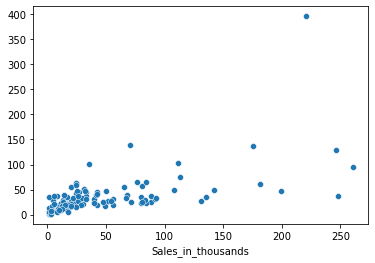

In [245]:
# corleations
sns.scatterplot( train.Sales_in_thousands, y_train_predicted )
plt.show()

C:\Users\DELL\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


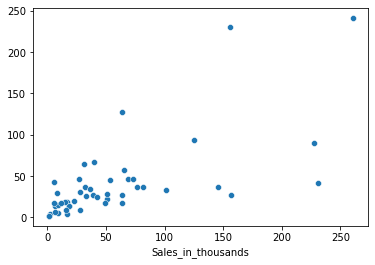

In [246]:
sns.scatterplot( test.Sales_in_thousands, y_test_predicted )
plt.show()

In [249]:
lm3.resid

135   -0.295283
77     1.063329
18    -0.025717
48    -1.055286
4     -0.055138
         ...   
133    0.042320
137    1.879060
72    -0.774432
140    0.257439
37     1.044689
Length: 109, dtype: float64

C:\Users\DELL\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


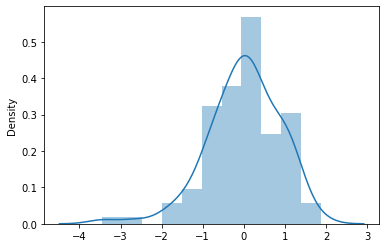

In [250]:
# assumption: Normality of the residuals/error (using distplot)
sns.distplot(lm3.resid)
plt.show()

In [252]:
# assumption: mean of residuals/errors is zero
print(lm3.resid.mean())

3.497304382892603e-14


In [253]:
# assumption: residuals/errors of the model should not be correlated with dependant (Y) variable
print(stats.stats.pearsonr(lm3.resid, train.ln_sales_in_thousands))

(0.7118084864271652, 4.100791461216437e-18)


C:\Users\DELL\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


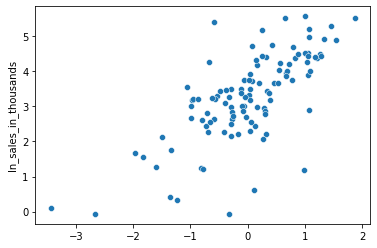

In [254]:
# assumption: homoscedasticity of residuals/errors
sns.scatterplot(lm3.resid, train.ln_sales_in_thousands)
plt.show()

### Decile analysis

In [258]:
train_data = pd.DataFrame( [train.Sales_in_thousands, y_train_predicted] ).T
test_data = pd.DataFrame( [test.Sales_in_thousands, y_test_predicted] ).T

train_data.columns = ['y_actual', 'y_predicted']
test_data.columns = ['y_actual', 'y_predicted']

In [262]:
train_data['deciles'] = pd.qcut( train_data.y_predicted, 10, range(1, 11) )
test_data['deciles'] = pd.qcut( test_data.y_predicted, 10, range(1, 11) )

In [267]:
decile_train = train_data.groupby('deciles').mean().reset_index().sort_values(by = 'deciles', ascending=False)
decile_test = test_data.groupby('deciles').mean().reset_index().sort_values(by = 'deciles', ascending=False)

In [268]:
decile_train

,deciles,y_actual,y_predicted
9,10,128.820756,124.479345
8,9,69.147909,54.007330
7,8,69.608909,42.422058
6,7,46.889091,35.667435
5,6,54.089100,30.899137
4,5,44.192909,25.946988
3,4,34.441364,22.739126
2,3,24.338818,18.365227
1,2,13.082844,13.006704
0,1,5.523025,5.310143


In [269]:
decile_test

,deciles,y_actual,y_predicted
9,10,166.446864,156.314536
8,9,55.468600,56.437543
7,8,79.617400,42.605356
6,7,72.451000,36.113648
5,6,50.347400,29.864658
4,5,64.436200,25.376862
3,4,26.008750,18.504128
2,3,21.696200,16.126942
1,2,14.874400,10.528853
0,1,5.972400,3.573811


#### What can be the possible reasons for poor model performance?

### Tips/guidlines for imporvement of model accuracy